Phase 1: Clustering for Multi-Stage Failure Labeling (Refined Version)
- Loads CMAPSS data (FD001) using the specified column names.
- Includes sensor grouping information for context.
- Preprocesses sensor data (scaling with StandardScaler, handling low variance).
- Applies KMeans (k=5) clustering to high-dimensional scaled sensor data.
- Interprets clusters based on time ('time_in_cycles') progression to define 5 stages.
- Visualizes results (Distribution, PCA by stage, Sensor Trends by stage).
- Strictly avoids using any pre-existing RUL information.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score, accuracy_score)
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import SVC, NuSVR
import warnings
import time
import os

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

In [27]:
DATASET_PATH = 'CMaps/' #Path of the Datasets
DATASET_IDS = ['FD001', 'FD003'] # Example: Combine FD001 and FD003
# DATASET_IDS = ['FD002', 'FD004'] # Example: Combine FD002 and FD004
# DATASET_IDS = ['FD001', 'FD002', 'FD003', 'FD004']
N_CLUSTERS = 5       # Number of degradation stages (0: Normal -> 4: Failure)
RANDOM_STATE = 42
print(f"Using Dataset IDs: {DATASET_IDS}")
COMBINED_DATASET_NAME = "+".join(DATASET_IDS)
print(f"Number of Degradation Stages to derive: {N_CLUSTERS}")

# Sensor grouping information just for context
sensor_groups = {
    'temperature': ['sensor_2', 'sensor_3', 'sensor_4'],
    'pressure': ['sensor_8', 'sensor_9', 'sensor_10', 'sensor_11'],
    'rpm': ['sensor_12', 'sensor_13'],
    'flow': ['sensor_5', 'sensor_6', 'sensor_7', 'sensor_14', 'sensor_15'],
    # Note: sensor_16 to sensor_21 are not explicitly grouped here
}
print("\nSensor Grouping Information (for context):\n")
for group, sensors in sensor_groups.items():
    print(f"{group}: {', '.join(sensors)}")

Using Dataset IDs: ['FD001', 'FD003']
Number of Degradation Stages to derive: 5

Sensor Grouping Information (for context):

temperature: sensor_2, sensor_3, sensor_4
pressure: sensor_8, sensor_9, sensor_10, sensor_11
rpm: sensor_12, sensor_13
flow: sensor_5, sensor_6, sensor_7, sensor_14, sensor_15


In [28]:
#Plotting function to plot distribution of samples across the degradation stages that we derives
def plot_cluster_distribution(df, stage_col):
    """Distribution of samples across the derived degradation stages."""
    plt.figure(figsize=(8, 5))
    sns.countplot(x=stage_col, data=df, order=sorted(df[stage_col].unique()))
    plt.title(f'Distribution of Samples Across {N_CLUSTERS} Degradation Stages')
    plt.xlabel('Degradation Stage')
    plt.ylabel('Number of Samples')
    plt.grid(axis='y', linestyle='--')
    plt.show()

In [29]:
def plot_pca_clusters(X_pca, labels):
    """Plots the clusters using PCA results"""
    plt.figure(figsize=(10, 7))
    unique_labels = sorted(np.unique(labels))
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

    for i, label in enumerate(unique_labels):
        cluster_points = X_pca[labels == label]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                    color=colors[i],
                    label=f'Stage {label}', # Label directly with the stage number
                    alpha=0.5, s=8)

    plt.title('Sensor Data Clusters Visualized with PCA')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title="Degradation Stage", markerscale=2)
    plt.grid(True, linestyle='--')
    plt.show()

In [30]:
def plot_sensor_trends_by_stage(df, sensor_cols_to_plot, stage_col, sample_engines):
    """Plots sensor trends over time for sample engines"""
    print(f"\nPlotting sensor trends for sample engines: {sample_engines}")
    # Ensure df is sorted by unit_number and time_in_cycles for correct line plotting
    df_sorted = df.sort_values(by=['unit_number', 'time_in_cycles'])
    sample_df = df_sorted[df_sorted['unit_number'].isin(sample_engines)].copy()

    if sample_df.empty:
        print(f"Warning: No data found for sample engines {sample_engines}.")
        return

    num_sensors = len(sensor_cols_to_plot)
    num_cols = 3
    num_rows = (num_sensors + num_cols - 1) // num_cols

    plt.figure(figsize=(num_cols * 6, num_rows * 4))
    unique_stages = sorted(sample_df[stage_col].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_stages)))
    stage_color_map = {stage: colors[i] for i, stage in enumerate(unique_stages)}

    for i, sensor in enumerate(sensor_cols_to_plot):
        ax = plt.subplot(num_rows, num_cols, i + 1)

        for engine_id in sample_engines:
            engine_data = sample_df[sample_df['unit_number'] == engine_id]
            if not engine_data.empty:
                scatter = ax.scatter(engine_data['time_in_cycles'], engine_data[sensor],
                                     c=engine_data[stage_col], cmap='viridis', vmin=min(unique_stages), vmax=max(unique_stages),
                                     s=10, alpha=1.0, label=f'Engine {engine_id}' if sensor == sensor_cols_to_plot[0] else "")
                ax.plot(engine_data['time_in_cycles'], engine_data[sensor], '-', lw=0.7, alpha=0.8, color='gray')


        ax.set_title(f'{sensor} Trend (Scaled)')
        ax.set_xlabel('Time in Cycles')
        ax.set_ylabel('Scaled Sensor Value')
        ax.grid(True, linestyle='--')

        if i == 0:
             handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=stage_color_map[stage], markersize=8) for stage in unique_stages]
             labels = [f'Stage {stage}' for stage in unique_stages]
             stage_legend = ax.legend(handles, labels, title="Degradation Stage", loc='best')


    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(f'Sensor Trends for Engines {sample_engines}', fontsize=16, y=0.99)
    plt.show()

In [ ]:
try:
    # Define column names (ensure these are generally applicable or adjust if needed)
    columns = ['unit_number', 'time_in_cycles'] + \
              [f'operational_setting_{i}' for i in range(1, 4)] + \
              [f'sensor_{i}' for i in range(1, 22)]

    all_dfs = []
    print(f"\n--- Loading Data for Datasets: {DATASET_IDS} ---")
    for fd_id in DATASET_IDS:
        filepath = f"{DATASET_PATH}/train_{fd_id}.txt"
        print(f"Attempting to load: {filepath}")
        try:
            df = pd.read_csv(
                filepath,
                sep=r'\s+',
                header=None,
                names=columns,
                engine='python',
                # Handle potential extra columns in some files if needed
                on_bad_lines='warn' # or 'skip'
            )
            df['dataset_id'] = fd_id # Add dataset identifier

            # *** MOST CRITICAL CHANGE: Create unique unit numbers ***
            df['unit_number'] = df['dataset_id'] + '_' + df['unit_number'].astype(str)

            print(f"Successfully loaded train_{fd_id}.txt. Shape: {df.shape}")
            all_dfs.append(df)
        except FileNotFoundError:
            print(f"Error: File not found at '{filepath}'.")
            # Decide behavior: exit() or warn and continue
            print(f"Warning: Skipping dataset {fd_id}.")
        except Exception as e:
            print(f"An error occurred loading {filepath}: {e}")
            # Decide behavior: exit() or warn and continue
            # exit()

    if not all_dfs:
         print("Error: No data was loaded successfully. Exiting.")
         exit()

    # Concatenate all loaded dataframes
    df_train_raw = pd.concat(all_dfs, ignore_index=True)
    print(f"\nCombined raw data shape: {df_train_raw.shape}")
    print("Sample of combined data (note unique 'unit_number'):")
    print(df_train_raw.head())

    # --- Optional but Recommended: Filter to Common Columns ---
    # Use this especially if combining across FD001/3 and FD002/4
    if len(DATASET_IDS) > 1:
         print("\nIdentifying common columns across loaded datasets...")
         # Get column sets, handle potential loading errors if a df is None
         col_sets = [set(df.columns) for df in all_dfs if df is not None]
         if not col_sets:
             print("Error: Could not determine columns. Exiting.")
             exit()
         common_cols_set = col_sets[0].intersection(*col_sets[1:])
         desired_order = ['unit_number', 'time_in_cycles', 'dataset_id'] + \
                         [f'operational_setting_{i}' for i in range(1, 4)] + \
                         [f'sensor_{i}' for i in range(1, 22)]
         final_ordered_common_cols = [col for col in desired_order if col in common_cols_set]
         print(f"Found {len(final_ordered_common_cols)} common columns. Processing using these in defined order.")
         # Ensure essential columns are kept if somehow dropped
         df_train_raw = df_train_raw[final_ordered_common_cols]
         print(f"Data filtered to common columns. New shape: {df_train_raw.shape}")

except Exception as e: # General Error Handling for the loading block
    print(f"An critical error occurred during data loading/combining: {e}")
    exit()

# --- Redefine column lists based on the FINAL df_train_raw ---
print("\nIdentifying final feature columns...")
all_available_columns = df_train_raw.columns
sensor_cols_initial = [col for col in all_available_columns if col.startswith('sensor_')]
op_setting_cols_initial = [col for col in all_available_columns if col.startswith('operational_setting_')]
print(f"Initially found {len(sensor_cols_initial)} sensor columns and {len(op_setting_cols_initial)} operational setting columns.")
# Check if essential columns exist
if not all(col in df_train_raw.columns for col in ['unit_number', 'time_in_cycles']):
     print("Error: Essential columns ('unit_number', 'time_in_cycles') missing after loading/filtering.")
     exit()
df_train_processed = df_train_raw.copy()

print("\nDefining Operating Conditions")
op_setting_cols_present = [col for col in op_setting_cols_initial if col in df_train_processed.columns]
if not op_setting_cols_present:
    print("Warning: No operational setting columns found. Assuming single operating condition.")
    df_train_processed['op_condition_id'] = 0
else:
    print(f"Using operational setting columns to define conditions: {op_setting_cols_present}")
    # Round op_settings to create discrete condition IDs. Adjust precision as needed.
    # For FD002/FD004, 2 decimal places usually suffices for the 6 conditions.
    rounded_op_settings = df_train_processed[op_setting_cols_present].round(2)
    df_train_processed['op_condition_id'] = rounded_op_settings.apply(
        lambda x: '_'.join(x.astype(str)), axis=1
    )
    # Map string IDs to integer IDs
    op_condition_map = {val: i for i, val in enumerate(df_train_processed['op_condition_id'].unique())}
    df_train_processed['op_condition_id'] = df_train_processed['op_condition_id'].map(op_condition_map)

num_op_conditions = df_train_processed['op_condition_id'].nunique()
print(f"Identified {num_op_conditions} unique operating conditions.")
print("Distribution of data points per operating condition:")
print(df_train_processed['op_condition_id'].value_counts().sort_index())
print("Sample of data with op_condition_id:")
print(df_train_processed[['unit_number', 'time_in_cycles'] + op_setting_cols_present + ['op_condition_id']].head())


--- Loading Data for Datasets: ['FD001', 'FD003'] ---
Attempting to load: CMaps//train_FD001.txt
Successfully loaded train_FD001.txt. Shape: (20631, 27)
Attempting to load: CMaps//train_FD003.txt
Successfully loaded train_FD003.txt. Shape: (24720, 27)

Combined raw data shape: (45351, 27)
Sample of combined data (note unique 'unit_number'):
  unit_number  time_in_cycles  operational_setting_1  operational_setting_2  \
0     FD001_1               1                -0.0007                -0.0004   
1     FD001_1               2                 0.0019                -0.0003   
2     FD001_1               3                -0.0043                 0.0003   
3     FD001_1               4                 0.0007                 0.0000   
4     FD001_1               5                -0.0019                -0.0002   

   operational_setting_3  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  \
0                  100.0    518.67    641.82   1589.70   1400.60     14.62   
1                  100.0 

In [ ]:
# We will now determine active_sensor_cols after checking for low variance on df_train_processed.

print("Checking for low-variance sensors (globally)...")
current_sensor_cols = [col for col in sensor_cols_initial if col in df_train_processed.columns]

if not current_sensor_cols:
    print("Error: No sensor columns found in df_train_processed to check for low variance.")
    exit()

sensor_data_for_std_check = df_train_processed[current_sensor_cols]
sensor_std = sensor_data_for_std_check.std().sort_values()

std_threshold = 0.01 # Threshold for vaiance, any columns with variance below this threshold will be dropped
low_variance_sensors = sensor_std[sensor_std < std_threshold].index.tolist()

if low_variance_sensors:
    print(f"Dropping Sensors columns with std dev < {std_threshold}: {low_variance_sensors}")
    df_train_processed.drop(columns=low_variance_sensors, inplace=True)
    active_sensor_cols = [col for col in current_sensor_cols if col not in low_variance_sensors]
else:
    print(f"-> No sensors found with std dev < {std_threshold}. No sensors dropped.")
    active_sensor_cols = current_sensor_cols[:]

if not active_sensor_cols:
    print("Error: No active sensor columns remaining after low-variance check. Cannot proceed.")
    exit()
print(f"Selected {len(active_sensor_cols)} active sensor columns: {active_sensor_cols[:5]}...")

# Condition-Specific Scaling for Active Sensor Data
print("\nScaling active sensor data *within each operating condition* using StandardScaler...")
scaled_sensor_data_list = []
for condition_id, group_df in df_train_processed.groupby('op_condition_id'):
    group_copy = group_df.copy() # Work on a copy
    scaler_sensors_condition = StandardScaler()
    group_copy[active_sensor_cols] = scaler_sensors_condition.fit_transform(group_df[active_sensor_cols])
    scaled_sensor_data_list.append(group_copy)

# Concatenate back, ensuring original index is preserved for potential future merges
df_train_processed = pd.concat(scaled_sensor_data_list).sort_index()

print("Active sensor data scaled within each operating condition.")
print("Displaying a sample of processed data (sensor values are now condition-scaled):")
print(df_train_processed[['unit_number', 'time_in_cycles', 'op_condition_id'] + active_sensor_cols].head())

Checking for low-variance sensors...
Dropping Sensors columns with std dev < 0.01: ['sensor_1', 'sensor_18', 'sensor_19', 'sensor_16', 'sensor_5', 'sensor_10']

Scaling active sensor data using StandardScaler...
Active sensor data scaled.
  unit_number  time_in_cycles dataset_id  operational_setting_1  \
0     FD001_1               1      FD001                -0.0007   
1     FD001_1               2      FD001                 0.0019   
2     FD001_1               3      FD001                -0.0043   
3     FD001_1               4      FD001                 0.0007   
4     FD001_1               5      FD001                -0.0019   

   operational_setting_2  operational_setting_3  sensor_2  sensor_3  sensor_4  \
0                -0.0004                  100.0 -1.409364  0.076860 -0.609157   
1                -0.0003                  100.0 -0.780302  0.396965 -0.346968   
2                 0.0003                  100.0 -0.399052 -0.181338 -0.237551   
3                 0.0000          

In [33]:
print(f"Applying KMeans clustering with k={N_CLUSTERS} on scaled sensor data...")
clustering_features = df_train_processed[active_sensor_cols]

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10,algorithm='lloyd')
df_train_processed['cluster_label'] = kmeans.fit_predict(clustering_features)
print("Distribution of raw cluster labels:")
print(df_train_processed['cluster_label'].value_counts().sort_index())

Applying KMeans clustering with k=5 on scaled sensor data...
Distribution of raw cluster labels:
cluster_label
0    16276
1     4286
2     6193
3    15849
4     2747
Name: count, dtype: int64


In [34]:
print("Interpreting clusters based on average time_in_cycles...")

cluster_avg_time = df_train_processed.groupby('cluster_label')['time_in_cycles'].mean().sort_values() #calculating the mean of each cluster and sorting

print("\nAverage 'time_in_cycles' for each raw cluster label (sorted):")
print(cluster_avg_time)

# Now we map these clusters to the degradation stages
stage_map = {cluster_label: stage for stage, cluster_label in enumerate(cluster_avg_time.index)}

print("\nMapping from raw cluster label to degradation stage:")
df = pd.DataFrame(list(stage_map.items()), columns=["Cluster Number", "Degradation Stage"])
print(df)

# Apply the mapping
df_train_processed['degradation_stage'] = df_train_processed['cluster_label'].map(stage_map)

Interpreting clusters based on average time_in_cycles...

Average 'time_in_cycles' for each raw cluster label (sorted):
cluster_label
3     96.092940
0    101.332514
1    121.435138
2    191.612143
4    292.468147
Name: time_in_cycles, dtype: float64

Mapping from raw cluster label to degradation stage:
   Cluster Number  Degradation Stage
0               3                  0
1               0                  1
2               1                  2
3               2                  3
4               4                  4


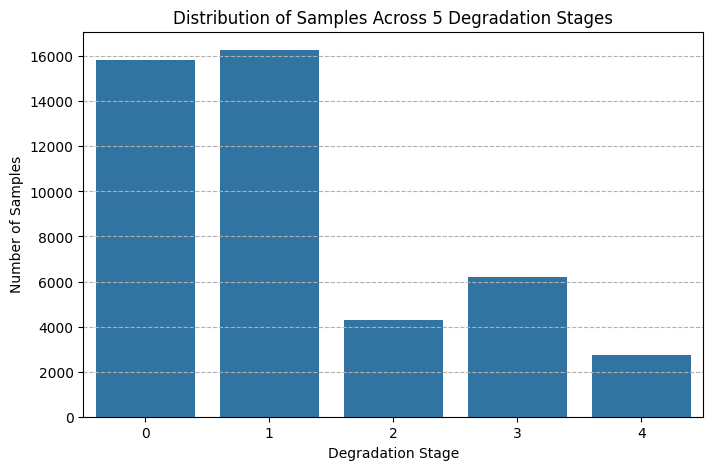

PCA complete. Explained variance ratio by 2 components: 0.7285


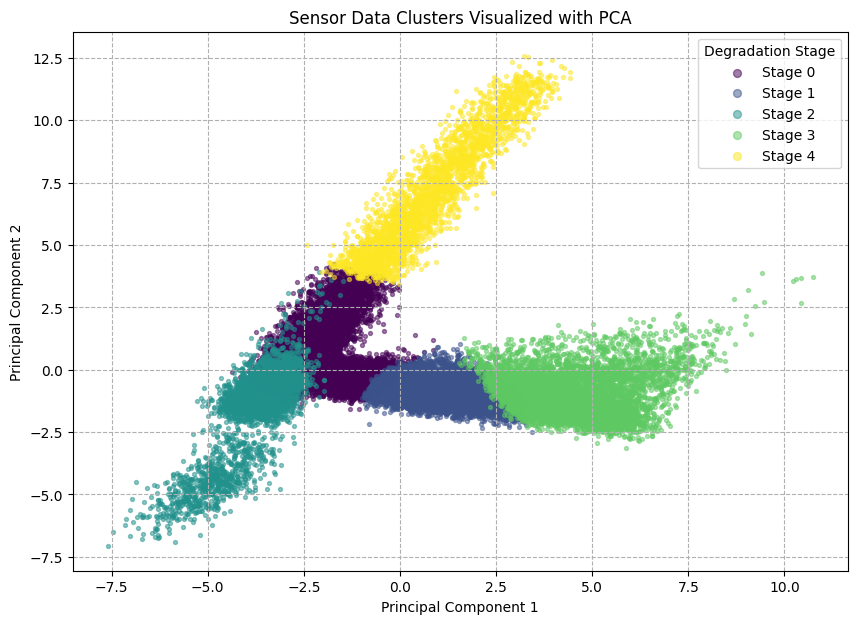

Visualizing sensor trends colored by derived degradation stage...

Plotting sensor trends for sample engines: ['FD001_1', 'FD001_2', 'FD003_1', 'FD003_2']


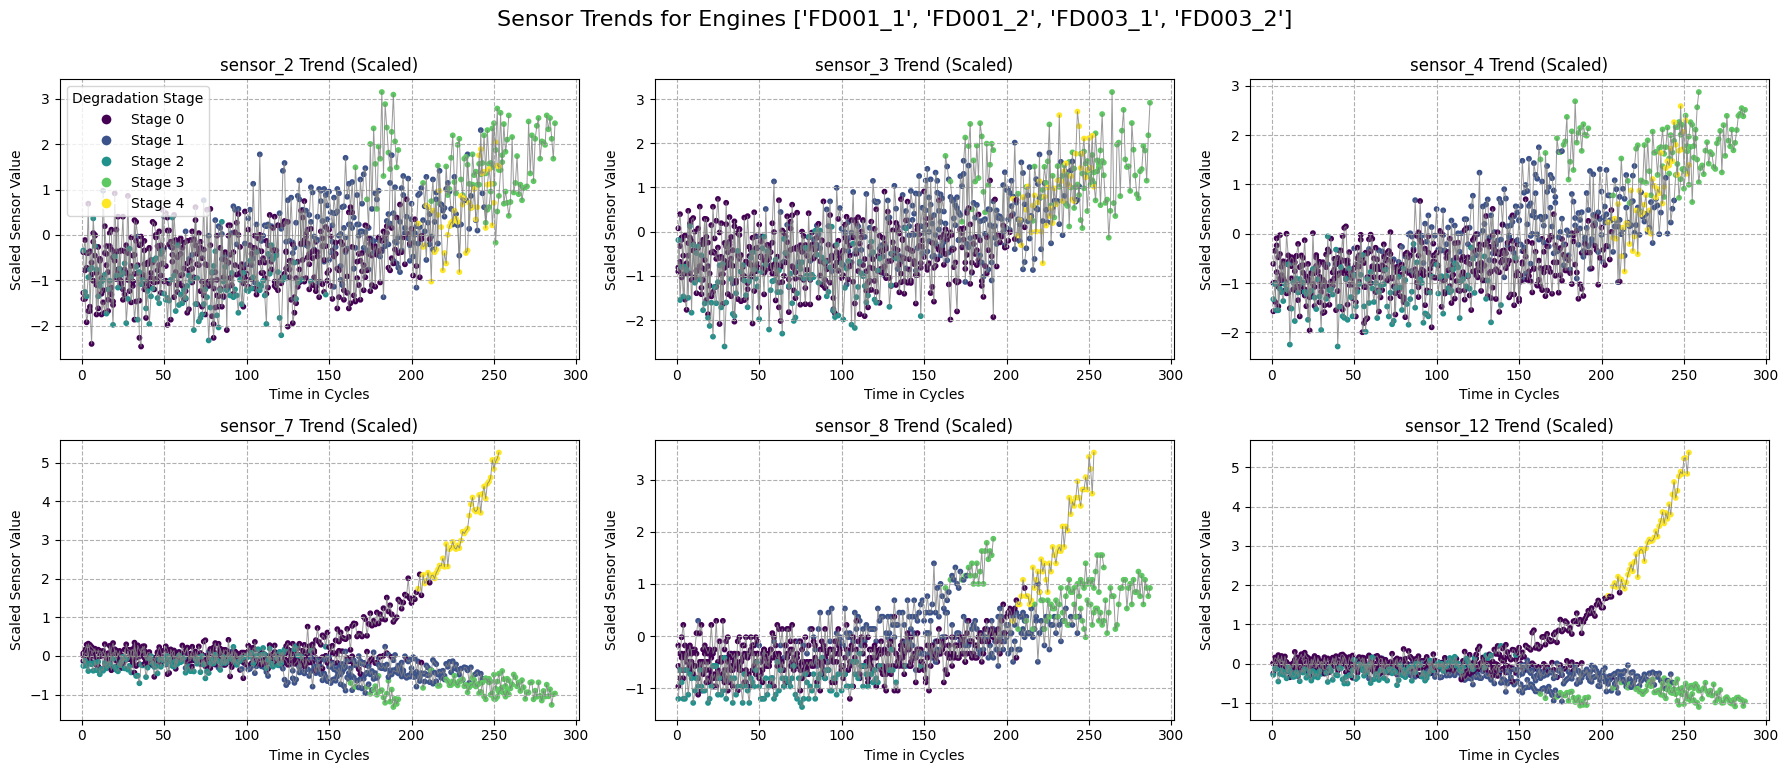

In [35]:
# 1. Distribution plot forr samples across degradation stages
plot_cluster_distribution(df_train_processed, 'degradation_stage')

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(df_train_processed[active_sensor_cols])
print(f"PCA complete. Explained variance ratio by 2 components: {pca.explained_variance_ratio_.sum():.4f}")
plot_pca_clusters(X_pca, df_train_processed['degradation_stage']) # Color by the final mapped stage

# 3. Sensor Trends Visualization for saple engines
print("Visualizing sensor trends colored by derived degradation stage...")
sensors_to_plot = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_12'] #Random sensors that we are using to plot trends
unique_engine_ids = df_train_processed['unit_number'].unique()
sample_engines_list = []
if len(DATASET_IDS) > 1:
    for d_id in DATASET_IDS:
        # Find engines belonging to this dataset
        engines_from_dset = [eng for eng in unique_engine_ids if eng.startswith(d_id + '_')]
        # Take first 2 (or adjust) if available
        sample_engines_list.extend(engines_from_dset[:2])
    # Ensure we have max 5-6 samples total
    PLOT_SAMPLE_ENGINES = sample_engines_list[:min(len(sample_engines_list), 5)]
else: # Only one dataset loaded
     PLOT_SAMPLE_ENGINES = list(unique_engine_ids[:min(len(unique_engine_ids), 5)])
sensors_to_plot = [s for s in sensors_to_plot if s in active_sensor_cols]
if not sensors_to_plot: # Fallback if all selected were dropped
    sensors_to_plot = active_sensor_cols[:min(len(active_sensor_cols), 6)]

plot_sensor_trends_by_stage(df_train_processed, sensors_to_plot, 'degradation_stage', PLOT_SAMPLE_ENGINES)


Applying Gaussian Mixture Model (n_components=5)...
GMM fitting completed in 4.78 seconds.
Distribution of raw GMM cluster labels:
gmm_cluster_label
0    24763
1     9549
2     1197
3     6658
4     3184
Name: count, dtype: int64

Interpreting GMM clusters based on average time_in_cycles...
GMM Stage Mapping (Cluster -> Stage): {2: 0, 0: 1, 1: 2, 3: 3, 4: 4}


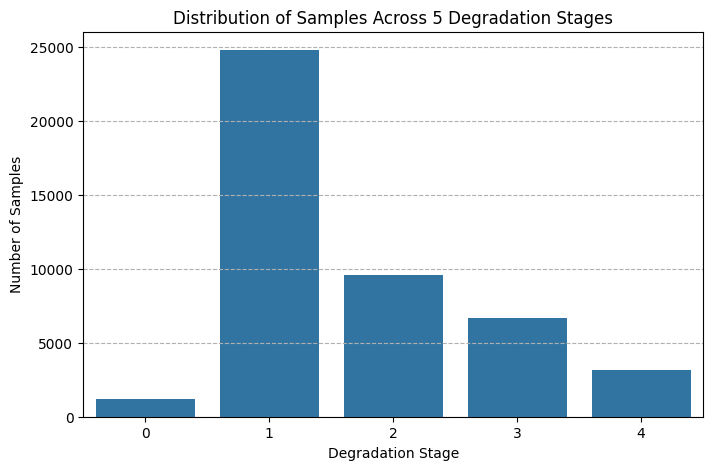

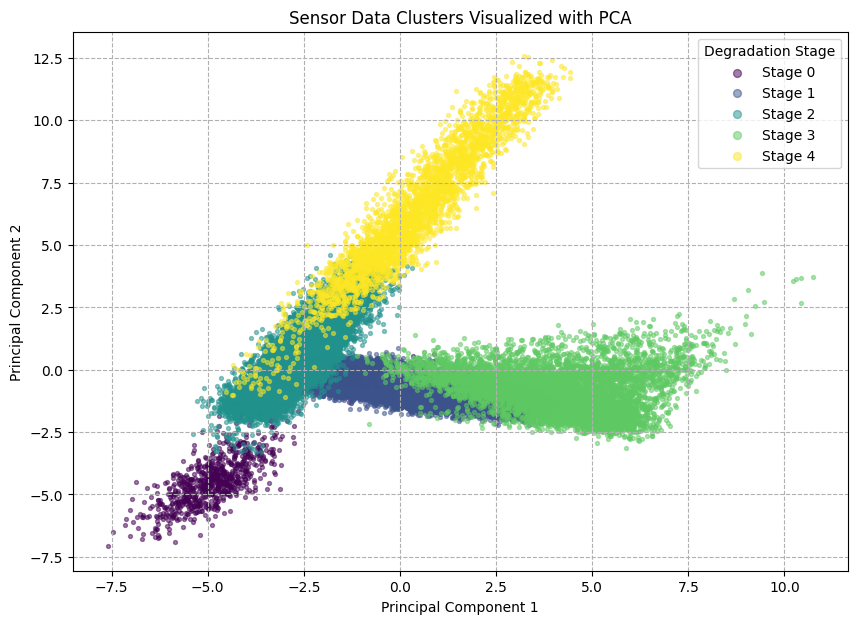

In [ ]:
# Clustering Model 2: Gaussian Mixture Model (GMM)
print(f"\nApplying Gaussian Mixture Model (n_components={N_CLUSTERS})...")
start_time = time.time()
# covariance_type can be 'full', 'tied', 'diag', 'spherical'
# 'full' is most flexible, 'diag' might be faster/more stable
gmm = GaussianMixture(n_components=N_CLUSTERS,
                      covariance_type='full', # Try 'diag' if 'full' is slow or unstable
                      random_state=RANDOM_STATE,
                      n_init=5, # Number of initializations
                      max_iter=150 # Max iterations for convergence
                     )
# .fit_predict assigns each sample to the most likely Gaussian component
df_train_processed['gmm_cluster_label'] = gmm.fit_predict(clustering_features)
end_time = time.time()
print(f"GMM fitting completed in {end_time - start_time:.2f} seconds.")
print("Distribution of raw GMM cluster labels:")
print(df_train_processed['gmm_cluster_label'].value_counts().sort_index())

# Interpret GMM clusters based on time (same logic as before)
print("\nInterpreting GMM clusters based on average time_in_cycles...")
gmm_cluster_avg_time = df_train_processed.groupby('gmm_cluster_label')['time_in_cycles'].mean().sort_values()
gmm_stage_map = {cluster_label: stage for stage, cluster_label in enumerate(gmm_cluster_avg_time.index)}
df_train_processed['gmm_stage'] = df_train_processed['gmm_cluster_label'].map(gmm_stage_map)
print("GMM Stage Mapping (Cluster -> Stage):", gmm_stage_map)

# Visualize GMM results (add corresponding calls to plotting functions)
plot_cluster_distribution(df_train_processed, 'gmm_stage')
plot_pca_clusters(X_pca, df_train_processed['gmm_stage'])
# Optionally plot sensor trends using gmm_stage
# plot_sensor_trends_by_stage(df_train_processed, sensors_to_plot_active, 'gmm_stage', PLOT_SAMPLE_ENGINES, title_prefix="GMM: ")

Phase 1 Complete
The DataFrame 'df_train_processed' now includes:
  - Scaled active sensor data
  - 'cluster_label': Raw label from KMeans (0 to 4)
  - 'degradation_stage': Interpreted stage based on time_in_cycles (0=Normal to 4=Failure)

Phase 2: Classification Model (Predicting Degradation Stage)
- Uses the clustered-labeled data from Phase 1.
- Defines features (scaled sensors + operational settings) and target (degradation_stage).
- Scales operational settings.
- Splits data into training and validation sets (stratified).
- Trains a RandomForestClassifier with balanced class weights.
- Evaluates performance using classification report and confusion matrix.
- Plots feature importances.

Step 1: Define Features (X) and Target (y)

We are also adding rolling features to the data.

Features: Scaled active sensors + operational settings

Target: degradation_stage derived from clustering

In [ ]:
window_size = 50 # Window size for rolling features
rolling_features_list = []

print(f"Calculating rolling features on {len(active_sensor_cols)} condition-scaled active sensor columns.")
for col in active_sensor_cols: # These are now condition-scaled
    mean_col = f'{col}_roll_mean_{window_size}'
    std_col = f'{col}_roll_std_{window_size}'
    df_train_processed[mean_col] = df_train_processed.groupby('unit_number')[col].rolling(window=window_size, min_periods=1).mean().reset_index(level=0, drop=True)
    df_train_processed[std_col] = df_train_processed.groupby('unit_number')[col].rolling(window=window_size, min_periods=1).std().reset_index(level=0, drop=True)
    rolling_features_list.extend([mean_col, std_col])

# Fill initial NaNs from rolling window (using backfill then forward fill)
if rolling_features_list: # Check if list is not empty
    df_train_processed[rolling_features_list] = df_train_processed.groupby('unit_number')[rolling_features_list].fillna(method='bfill').fillna(method='ffill')
    # Handle any remaining NaNs if an engine has fewer cycles than window size
    df_train_processed[rolling_features_list] = df_train_processed[rolling_features_list].fillna(0) # Fill remaining NaNs for rolling features with 0
    print(f"Added {len(rolling_features_list)} rolling window features.")
else:
    print("No rolling features were added (perhaps no active sensor columns).")
# Handle any remaining NaNs if an engine has fewer cycles than window size
df_train_processed.fillna(0, inplace=True)

features_to_use = active_sensor_cols + op_setting_cols_present + rolling_features_list # features to include sensor data oprational settings and rolling features
features_to_use = [f for f in features_to_use if f in df_train_processed.columns] # Ensure all features exist in the final DataFrame
features_needing_global_scaling = op_setting_cols_present + rolling_features_list
features_needing_global_scaling = [f for f in features_needing_global_scaling if f in df_train_processed.columns]

target = 'degradation_stage'

X = df_train_processed[features_to_use]
y = df_train_processed[target]
print(f"Features ({len(features_to_use)}): {features_to_use[:5]}...{features_to_use[-2:]}")
print(f"Target: {target}")
print(f"Features needing global scaling ({len(features_needing_global_scaling)}): {features_needing_global_scaling[:3]}...")

Added 30 rolling window features.
Features (48): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7']...['sensor_21_roll_mean_50', 'sensor_21_roll_std_50']
Target: degradation_stage


Step 2: Split into train and test data and scale

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,       # 80% training, 20% validation
    random_state=RANDOM_STATE,
    stratify=y           # Crucial for imbalanced classes
)

if features_needing_global_scaling: # Check if there are any features to scale
    print(f"\nGlobally scaling {len(features_needing_global_scaling)} features (op_settings, rolling features) for ML models...")
    scaler_global_ml = StandardScaler()
    X_train[features_needing_global_scaling] = scaler_global_ml.fit_transform(X_train[features_needing_global_scaling])
    X_val[features_needing_global_scaling] = scaler_global_ml.transform(X_val[features_needing_global_scaling])
    print("Op_settings and rolling features globally scaled for ML models.")
else:
    print("No op_settings or rolling features to globally scale for ML models (sensors are already condition-scaled).")

print("\nSample of X_train head after all processing:")
print(X_train.head())


Scaling 33 numeric features...
Numeric features scaled.


Step 3: Train the classifier models (XGBoost, Logistic Regression, Support Vector Classifier)

In [66]:
classifiers = {} # Dictionary to store trained models
classification_results = {} # Dictionary to store classification results

print("\nTraining Classifier 1: XGBoost...")
start_time = time.time()
xgb_classifier = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=N_CLUSTERS,
    n_estimators=800,
    learning_rate=0.1,
    max_depth=13,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.01,
    reg_lambda=0.5,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='gpu_hist',
    predictor='gpu_predictor',
    gpu_id=1
)
xgb_classifier.fit(X_train, y_train)
end_time = time.time()
print(f"XGBoost training completed in {end_time - start_time:.2f} seconds.")
classifiers['xgboost'] = xgb_classifier
print("XGBoost training complete.")

print("\nTraining Classifier 2: Logistic Regression...")
start_time = time.time()

logreg_classifier = LogisticRegression(
    random_state=RANDOM_STATE,
    multi_class='ovr',
    solver='liblinear',
    max_iter=1000, # Increased from default
    class_weight='balanced',
    n_jobs=-1
)
logreg_classifier.fit(X_train, y_train)
end_time = time.time()
print(f"Logistic Regression training completed in {end_time - start_time:.2f} seconds.")
classifiers['logistic_regression'] = logreg_classifier

print("\nTraining Classifier 3: Support Vector Classifier (SVC)...")
print("Warning: SVC training can be slow, especially with probability=True.")
start_time = time.time()

svc_classifier = SVC(
    random_state=RANDOM_STATE,
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True, # MUST be True for predict_proba needed later
    class_weight='balanced'
)
svc_classifier.fit(X_train, y_train)
end_time = time.time()
print(f"SVC training completed in {end_time - start_time:.2f} seconds.")
classifiers['svc'] = svc_classifier


Training Classifier 1: XGBoost...
XGBoost training completed in 15.64 seconds.
XGBoost training complete.

Training Classifier 2: Logistic Regression...
Logistic Regression training completed in 7.01 seconds.

Training Classifier 3: Support Vector Classifier (SVC)...
SVC training completed in 59.26 seconds.


Step 4: Classifier Evaluation

Evaluate the classifiers and store their prediction in a dataframe with probabilities


--- Evaluating Classifiers on Validation Set ---

--- Evaluation for: XGBOOST ---

Classification Report:
              precision    recall  f1-score   support

     Stage 0       0.98      0.98      0.98      3170
     Stage 1       0.97      0.98      0.97      3256
     Stage 2       0.98      0.97      0.97       857
     Stage 3       0.98      0.97      0.97      1239
     Stage 4       0.98      0.99      0.99       549

    accuracy                           0.98      9071
   macro avg       0.98      0.98      0.98      9071
weighted avg       0.98      0.98      0.98      9071

Overall Accuracy: 0.9755

Confusion Matrix:


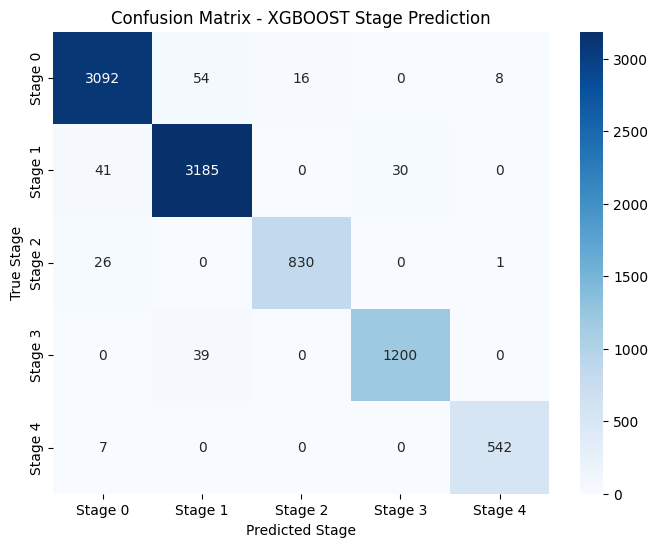


Plotting Feature Importances/Coefficients for XGBOOST...


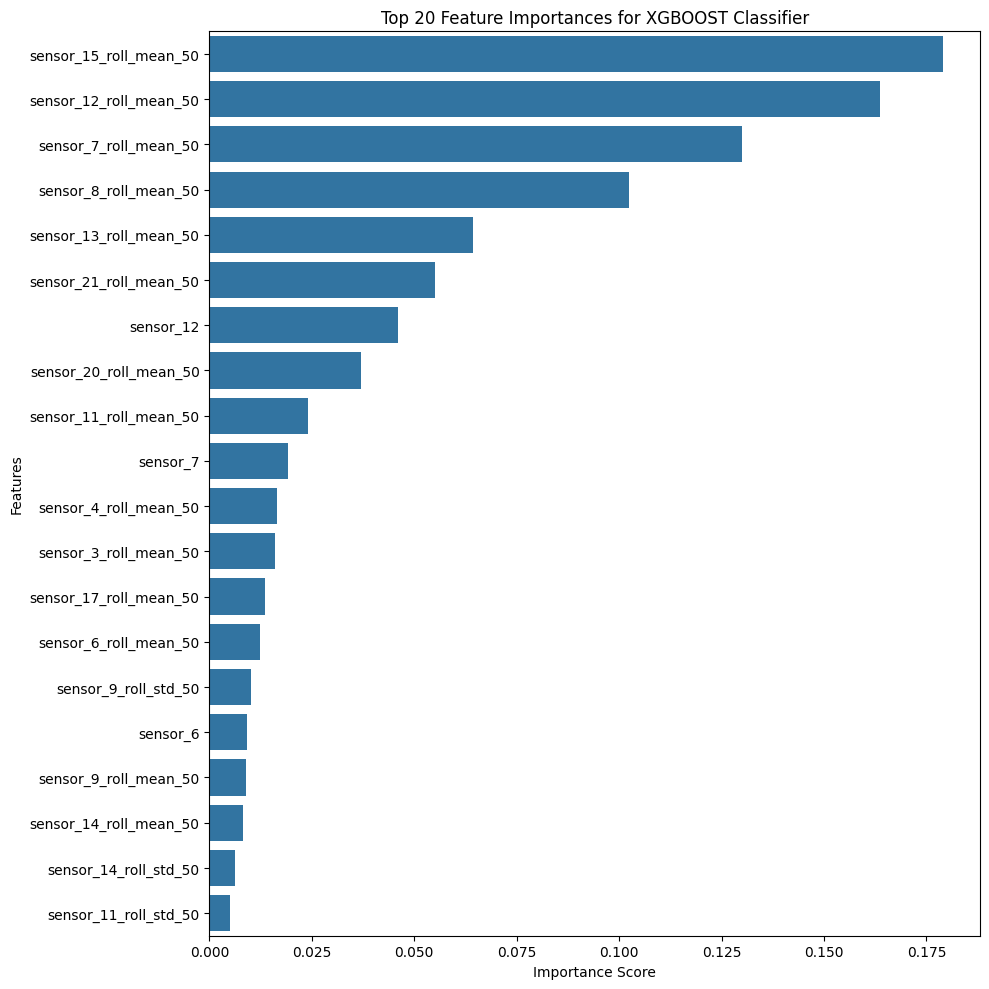


--- Evaluation for: LOGISTIC_REGRESSION ---

Classification Report:
              precision    recall  f1-score   support

     Stage 0       0.94      0.91      0.93      3170
     Stage 1       0.93      0.94      0.93      3256
     Stage 2       0.97      0.98      0.98       857
     Stage 3       0.96      0.99      0.98      1239
     Stage 4       0.94      0.99      0.96       549

    accuracy                           0.94      9071
   macro avg       0.95      0.96      0.95      9071
weighted avg       0.94      0.94      0.94      9071

Overall Accuracy: 0.9426

Confusion Matrix:


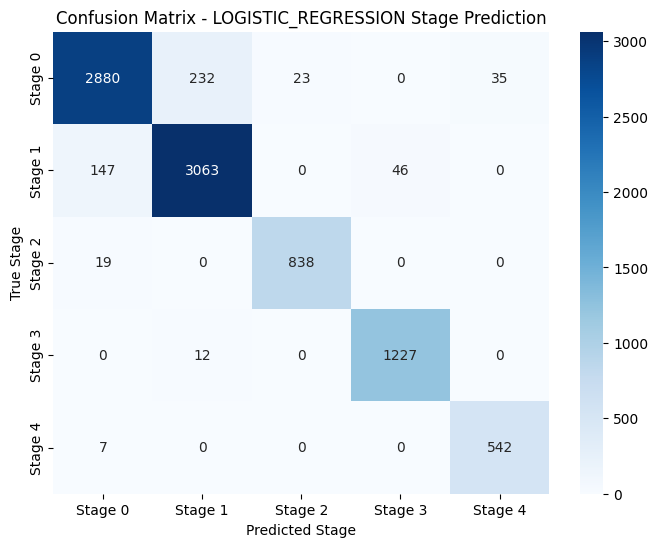


Plotting Feature Importances/Coefficients for LOGISTIC_REGRESSION...


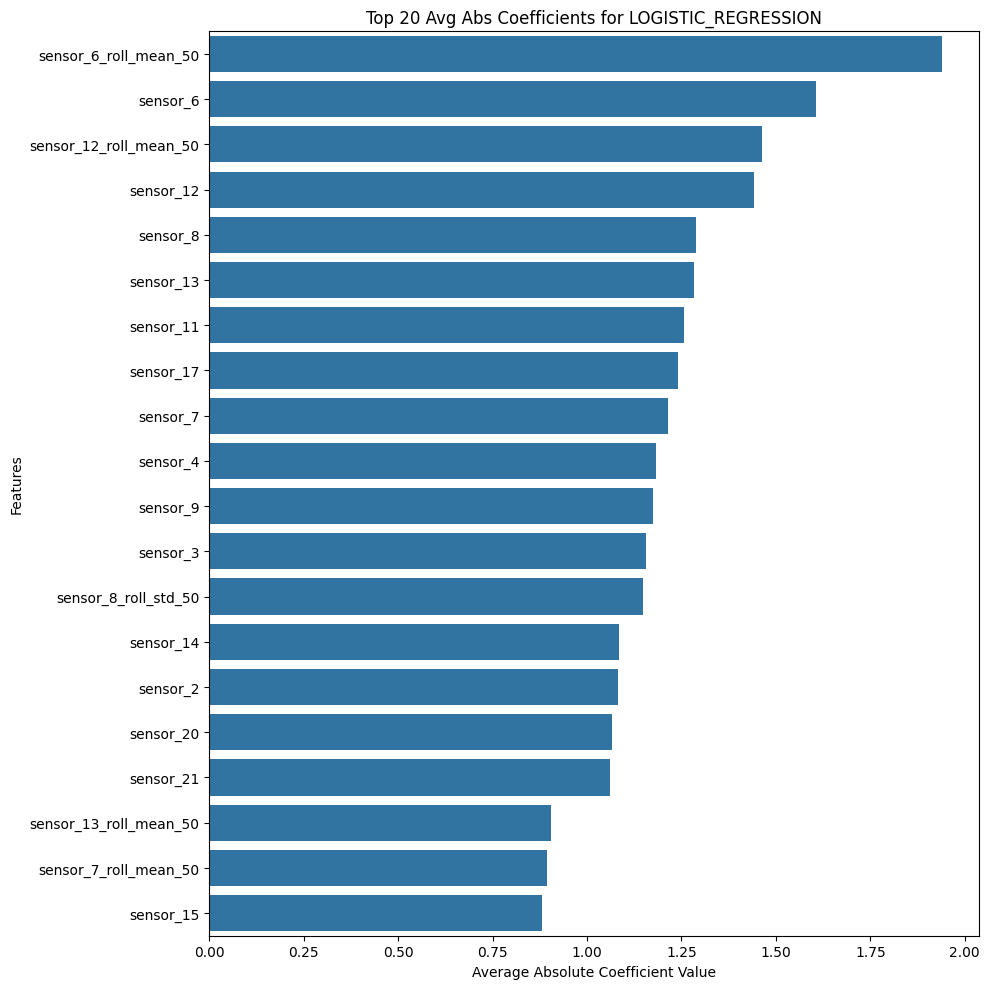


--- Evaluation for: SVC ---

Classification Report:
              precision    recall  f1-score   support

     Stage 0       0.99      0.97      0.98      3170
     Stage 1       0.99      0.97      0.98      3256
     Stage 2       0.95      0.99      0.97       857
     Stage 3       0.95      1.00      0.97      1239
     Stage 4       0.97      1.00      0.98       549

    accuracy                           0.98      9071
   macro avg       0.97      0.99      0.98      9071
weighted avg       0.98      0.98      0.98      9071

Overall Accuracy: 0.9793

Confusion Matrix:


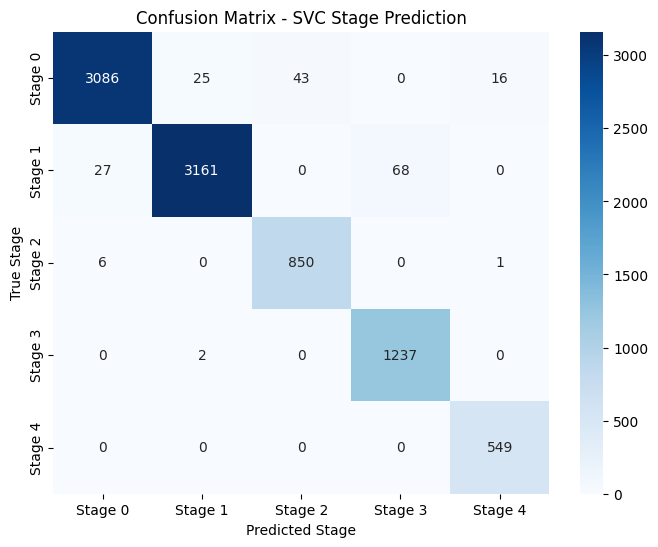


Plotting Feature Importances/Coefficients for SVC...
Feature importances or coefficients are not directly available for model type: SVC

Selected Best Classifier (based on Accuracy): SVC (Accuracy: 0.9793)

--- Phase 2 Evaluation Complete ---


In [40]:
# --- Step 4: Evaluate Classifiers ---
print("\n--- Evaluating Classifiers on Validation Set ---")
target_names = [f'Stage {i}' for i in range(N_CLUSTERS)]
df_val_results = X_val.copy()
df_val_results['true_stage'] = y_val
classification_accuracies = {}

# Loop through each trained classifier stored in the 'classifiers' dictionary
for name, model in classifiers.items():
    print(f"\n--- Evaluation for: {name.upper()} ---")
    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)
        # Store predictions and probabilities specific to this model
        df_val_results[f'predicted_stage_{name}'] = y_pred
        for i in range(N_CLUSTERS):
            # Ensure column name uniqueness for probabilities
            df_val_results[f'prob_stage_{i}_{name}'] = y_prob[:, i]
    else:
        print(f"Warning: predict_proba not available for model '{name}'. Skipping probability storage.")
        df_val_results[f'predicted_stage_{name}'] = y_pred

    try:
        df_val_results = df_val_results.merge(df_train_processed[['unit_number', 'time_in_cycles']],
                                          left_index=True, right_index=True, how='left')
    except NameError:
        print("Warning: df_train_processed not found for merging unit/cycle info. Results stored without them.")

    # 2. Classification Report & Accuracy
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=target_names, zero_division=0))
    # Calculate and print overall accuracy
    accuracy = accuracy_score(y_val, y_pred)
    classification_accuracies[name] = accuracy
    print(f"Overall Accuracy: {accuracy:.4f}")


    # 3. Confusion Matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.title(f'Confusion Matrix - {name.upper()} Stage Prediction')
    plt.xlabel('Predicted Stage')
    plt.ylabel('True Stage')
    plt.grid(False)
    plt.show()


    # 4. Feature Importance / Coefficients Plotting
    print(f"\nPlotting Feature Importances/Coefficients for {name.upper()}...")
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(
            model.feature_importances_,
            index=X_train.columns
        ).sort_values(ascending=False)

        # Plot top 20 features
        plt.figure(figsize=(10, max(6, len(importances.head(20)) // 2))) # Dynamic height
        sns.barplot(x=importances.head(20), y=importances.head(20).index)
        plt.title(f'Top 20 Feature Importances for {name.upper()} Classifier')
        plt.xlabel('Importance Score')
        plt.ylabel('Features')
        plt.tight_layout()
        plt.show()
    elif hasattr(model, 'coef_'):
        is_linear_svc = isinstance(model, SVC) and model.kernel == 'linear'
        is_logreg = isinstance(model, LogisticRegression)

        if is_logreg or is_linear_svc:
             if model.coef_.shape[0] > 1:
                 avg_abs_coef = np.mean(np.abs(model.coef_), axis=0)
                 importances = pd.Series(avg_abs_coef, index=X_train.columns).sort_values(ascending=False)
                 plot_title = f'Top 20 Avg Abs Coefficients for {name.upper()}'
                 xlabel = 'Average Absolute Coefficient Value'
             else:
                 importances = pd.Series(model.coef_[0], index=X_train.columns)
                 sorted_indices = importances.abs().sort_values(ascending=False).index
                 importances_sorted = importances[sorted_indices]
                 # Plot top 20
                 importances_to_plot = importances_sorted.head(20)
                 plot_title = f'Top 20 Coefficients for {name.upper()}'
                 xlabel = 'Coefficient Value'
                 plt.figure(figsize=(10, max(6, len(importances_to_plot) // 2)))
                 sns.barplot(x=importances_to_plot.values, y=importances_to_plot.index)
                 plt.title(plot_title)
                 plt.xlabel(xlabel)
                 plt.ylabel('Features')
                 plt.tight_layout()
                 plt.show()
                 continue

             # Standard plotting for averaged coefficients
             plt.figure(figsize=(10, max(6, len(importances.head(20)) // 2)))
             sns.barplot(x=importances.head(20), y=importances.head(20).index)
             plt.title(plot_title)
             plt.xlabel(xlabel)
             plt.ylabel('Features')
             plt.tight_layout()
             plt.show()
        else:
             print(f"Coefficient plotting not applicable for this model type ({type(model).__name__}) or kernel.")
    else:
        print(f"Feature importances or coefficients are not directly available for model type: {type(model).__name__}")

if classification_accuracies:
    best_classifier_name = max(classification_accuracies, key=classification_accuracies.get)
    best_accuracy = classification_accuracies[best_classifier_name]
    print(f"\nSelected Best Classifier (based on Accuracy): {best_classifier_name.upper()} (Accuracy: {best_accuracy:.4f})")

print(f"\n--- Phase 2 Evaluation Complete ---")

Phase 3: Time-to-next Stage prediction model

Step 1: Calculate the TTNS

In [41]:
# a) Find the first cycle number for each stage for each engine
first_cycle_per_stage = df_train_processed.groupby(['unit_number', 'degradation_stage'])['time_in_cycles'].min().unstack()
first_cycle_per_stage.columns = [f'first_cycle_stage_{i}' for i in range(N_CLUSTERS)]

# b) Get the maximum cycle for each engine (needed if next stage not reached)
engine_max_cycles = df_train_processed.groupby('unit_number')['time_in_cycles'].max()
print("Max cycles per engine computed.")

# c) Merge the first cycle info back into the main dataframe
df_train_processed = pd.merge(df_train_processed, first_cycle_per_stage, on='unit_number', how='left')
print("Merged first cycle data back.")

# d) Define a function to calculate TTNS for a row
def calculate_ttns(row):
    current_stage = int(row['degradation_stage'])
    max_stage = N_CLUSTERS - 1
    current_cycle = row['time_in_cycles']
    unit_num = row['unit_number']

    if current_stage == max_stage:
        return 0 # Already in the final stage

    next_stage = current_stage + 1
    next_stage_col = f'first_cycle_stage_{next_stage}'

    # Get the cycle number when the next stage first occurs for this engine
    try:
        next_stage_first_cycle = row[next_stage_col]
    except KeyError:
         max_cycle_for_engine = engine_max_cycles.loc[unit_num]
         return max(0, max_cycle_for_engine - current_cycle)

    if pd.isna(next_stage_first_cycle):
        # Engine never reached the next stage
        max_cycle_for_engine = engine_max_cycles.loc[unit_num]
        return max(0, max_cycle_for_engine - current_cycle)
    else:
        # Engine reached the next stage
        return max(0, next_stage_first_cycle - current_cycle)

df_train_processed['TTNS'] = df_train_processed.apply(calculate_ttns, axis=1)
print("TTNS calculated for all data points.")
print("Sample TTNS values:")
print(df_train_processed[['unit_number', 'time_in_cycles', 'degradation_stage', 'TTNS']].head())
print(df_train_processed[['unit_number', 'time_in_cycles', 'degradation_stage', 'TTNS']].tail())

Max cycles per engine computed.
Merged first cycle data back.
TTNS calculated for all data points.
Sample TTNS values:
  unit_number  time_in_cycles  degradation_stage  TTNS
0     FD001_1               1                  0  12.0
1     FD001_1               2                  0  11.0
2     FD001_1               3                  0  10.0
3     FD001_1               4                  0   9.0
4     FD001_1               5                  0   8.0
      unit_number  time_in_cycles  degradation_stage  TTNS
45346   FD003_100             148                  3   4.0
45347   FD003_100             149                  3   3.0
45348   FD003_100             150                  3   2.0
45349   FD003_100             151                  3   1.0
45350   FD003_100             152                  3   0.0


Step 2: Define X and Y and train the model

In [42]:
y_reg = df_train_processed['TTNS']
# Align target with the existing training and validation splits using indices
y_train_reg = y_reg.loc[y_train.index]
y_val_reg = y_reg.loc[y_val.index]
print(y_val_reg.mean())

95.46907727924155


In [67]:
regressors = {} # Dictionary for trained regressors
regression_results = {}

X_train_reg_feat_curr = X_train.copy()
X_val_reg_feat_curr = X_val.copy()

print("\nTraining Regressor 1: XGBoost...")
start_time = time.time()
regressor_XGB = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1200,
    learning_rate=0.009,
    max_depth=11,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='gpu_hist',
    predictor='gpu_predictor',
    gpu_id=1,
    random_state=RANDOM_STATE
)

#We are using the current_stage_feature to improve the prediction
X_train_reg_feat_curr['current_stage_feature'] = y_train 
X_val_reg_feat_curr['current_stage_feature'] = y_val
print("Added 'current_stage_feature' to regressor features.")

# Now fit using the augmented features
regressor_XGB.fit(X_train_reg_feat_curr, y_train_reg)
end_time = time.time()
regressors['xgboost'] = regressor_XGB
print(f"XGBoost Regressor training completed in {end_time - start_time:.2f} seconds.")

scaler_reg_features = StandardScaler()

X_train_reg_feat_scaled = scaler_reg_features.fit_transform(X_train_reg_feat_curr)
X_val_reg_feat_scaled = scaler_reg_features.transform(X_val_reg_feat_curr)

from sklearn.ensemble import HistGradientBoostingRegressor

print("\nTraining Regressor 2: HistGradientBoostingRegressor...")
start_time = time.time()
ridge_replacement = HistGradientBoostingRegressor(random_state=RANDOM_STATE)
ridge_replacement.fit(X_train_reg_feat_scaled, y_train_reg)
end_time = time.time()
print(f"HistGradientBoostingRegressor training completed in {end_time - start_time:.2f} seconds.")
regressors['HistGradientBoostingRegressor'] = ridge_replacement


print("\nTraining Regressor 3: NuSVR...")
start_time = time.time()
nu_svr = NuSVR(nu=0.5, C=15, gamma=0.01)
nu_svr.fit(X_train_reg_feat_scaled, y_train_reg)
end_time = time.time()
print(f"SVR training completed in {end_time - start_time:.2f} seconds.")
regressors['NuSVR'] = nu_svr


Training Regressor 1: XGBoost...
Added 'current_stage_feature' to regressor features.
XGBoost Regressor training completed in 54.48 seconds.

Training Regressor 2: HistGradientBoostingRegressor...
HistGradientBoostingRegressor training completed in 1.89 seconds.

Training Regressor 3: NuSVR...
SVR training completed in 74.00 seconds.


Step 3: Evaluate the model


Evaluating regressor on Validation Set...

Evaluating Regressor: XGBOOST

Regression Report (Validation Set):
Root Mean Squared Error (RMSE): 11.3247
Mean Absolute Error (MAE):    5.9714
R-squared (R²) Score:         0.9848


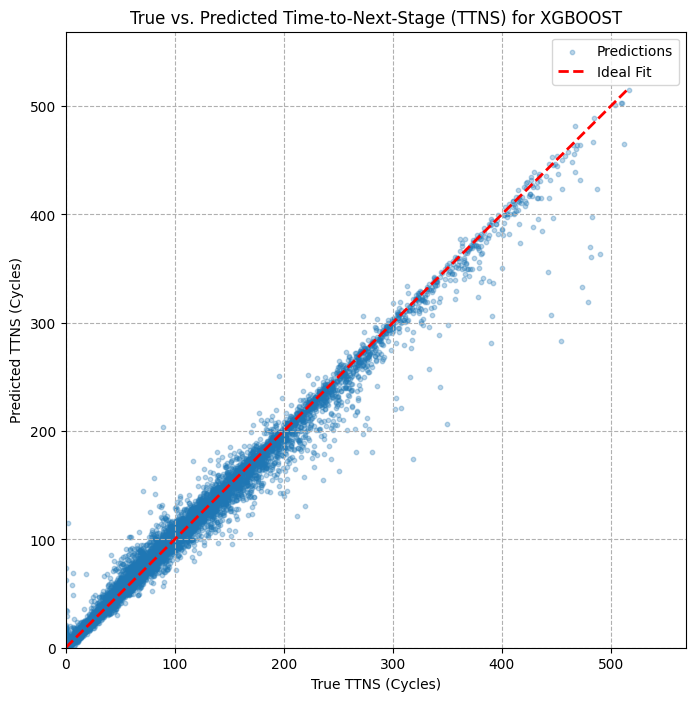


Evaluating Regressor: HISTGRADIENTBOOSTINGREGRESSOR

Regression Report (Validation Set):
Root Mean Squared Error (RMSE): 21.0926
Mean Absolute Error (MAE):    14.1112
R-squared (R²) Score:         0.9473


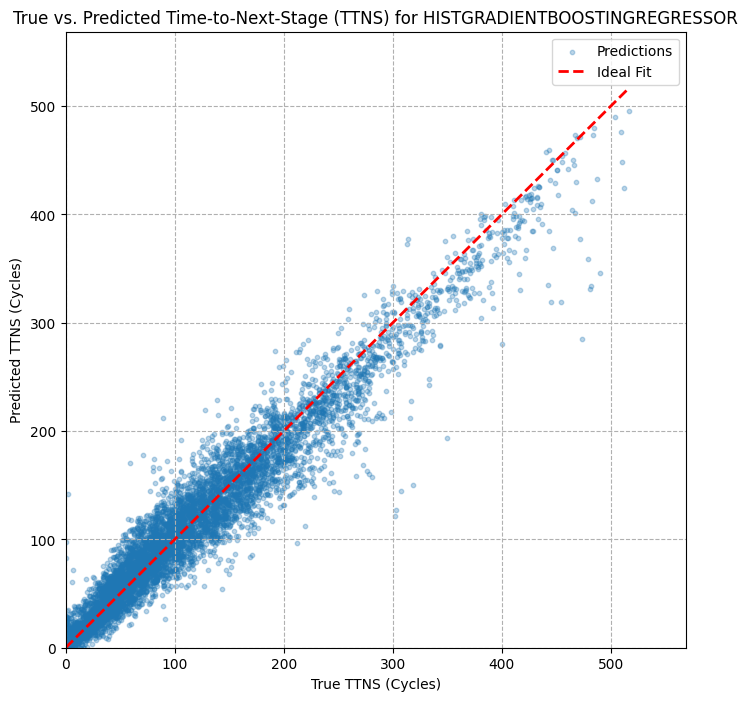


Evaluating Regressor: NUSVR

Regression Report (Validation Set):
Root Mean Squared Error (RMSE): 46.1812
Mean Absolute Error (MAE):    29.0221
R-squared (R²) Score:         0.7473


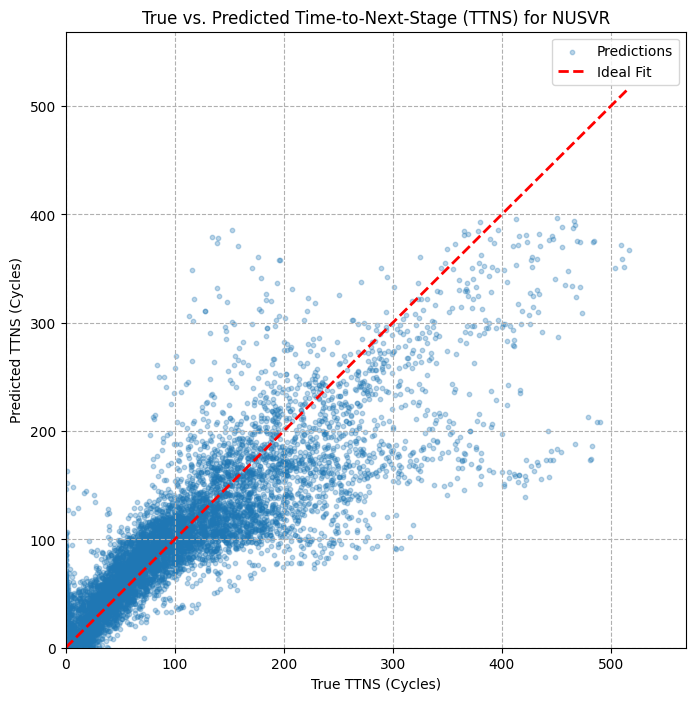

In [70]:
print("\nEvaluating regressor on Validation Set...")
regression_results = {}
df_val_results['true_ttns'] = y_val_reg
valid_ttns_indices = df_val_results.dropna(subset=['true_ttns']).index

for name, regressor in regressors.items():
    print(f"\nEvaluating Regressor: {name.upper()}")
    if name in ['HistGradientBoostingRegressor', 'NuSVR']:
        X_pred_features = X_val_reg_feat_scaled
    else:
        X_pred_features = X_val_reg_feat_curr

    y_pred_reg = regressor.predict(X_pred_features)
    y_pred_reg = np.maximum(y_pred_reg, 0)
    # Calculate metrics
    mse = mean_squared_error(y_val_reg, y_pred_reg)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val_reg, y_pred_reg)
    r2 = r2_score(y_val_reg, y_pred_reg)

    regression_results[name] = {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'y_pred': y_pred_reg 
    }

    print("\nRegression Report (Validation Set):")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE):    {mae:.4f}")
    print(f"R-squared (R²) Score:         {r2:.4f}")

    plt.figure(figsize=(8, 8))
    plt.scatter(y_val_reg, y_pred_reg, alpha=0.3, s=10, label='Predictions')
    plt.plot([y_val_reg.min(), y_val_reg.max()], [y_val_reg.min(), y_val_reg.max()], '--r', linewidth=2, label='Ideal Fit')
    plt.title(f'True vs. Predicted Time-to-Next-Stage (TTNS) for {name.upper()}')
    plt.xlabel('True TTNS (Cycles)')
    plt.ylabel('Predicted TTNS (Cycles)')
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.xlim([0, y_val_reg.max() * 1.1])
    plt.ylim([0, y_val_reg.max() * 1.1])
    plt.show()



Step 4: Add the results to our main data frame

In [72]:
best_model_name = min(regression_results, key=lambda k: regression_results[k]['rmse'])
best_rmse = regression_results[best_model_name]['rmse']
print(f"\nBest Regressor Selected")
print(f"Best performing regressor based on lowest RMSE: {best_model_name.upper()} (RMSE: {best_rmse:.4f})")
best_predictions_array = regression_results[best_model_name]['y_pred']
df_val_results['predicted_ttns'] = best_predictions_array

print("\nPhase 3 Complete")


Best Regressor Selected
Best performing regressor based on lowest RMSE: XGBOOST (RMSE: 11.3247)

Phase 3 Complete


Phase 4: Risk Score Calculation and normalization

Step 1: Calculate the risk scores and add them to the dataframe

In [74]:
failure_stage_prob_col = f'prob_stage_{N_CLUSTERS-1}_{best_classifier_name}'
time_left_col = 'predicted_ttns'
epsilon = 1e-6 # Small constant to prevent division by zero

print(f"Calculating Raw Risk Score using: {failure_stage_prob_col} / ({time_left_col} + epsilon)")

df_val_results['raw_risk_score'] = df_val_results[failure_stage_prob_col] / (df_val_results[time_left_col] + epsilon)

# Assign a very high risk in such cases by capping at slightly above the max finite risk
if np.isinf(df_val_results['raw_risk_score']).any():
    print("Handling infinite values in raw_risk_score...")
    max_finite_risk = df_val_results.loc[np.isfinite(df_val_results['raw_risk_score']), 'raw_risk_score'].max()
    df_val_results['raw_risk_score'] = df_val_results['raw_risk_score'].replace([np.inf, -np.inf], max_finite_risk * 1.1)
    print(f"Infinite values replaced with: {max_finite_risk * 1.1:.4f}")

Calculating Raw Risk Score using: prob_stage_4_svc / (predicted_ttns + epsilon)


Step 2: Normalize the risk score

In [75]:
#Step 2: Normalize Risk Score (Min-Max Scaling)
print("Normalizing Risk Score using Min-Max Scaling...")
min_risk = df_val_results['raw_risk_score'].min()
max_risk = df_val_results['raw_risk_score'].max()

print(f"Raw Risk Score Range: Min={min_risk:.4f}, Max={max_risk:.4f}")

# Avoid division by zero if all scores are identical
if max_risk > min_risk:
    df_val_results['normalized_risk_score'] = (df_val_results['raw_risk_score'] - min_risk) / (max_risk - min_risk)
else:
    df_val_results['normalized_risk_score'] = 0.0 # Assign 0 if range is zero
    print("Warning: Raw risk scores have zero range, normalized score set to 0.")

print(f"Normalized Risk Score Range: Min={df_val_results['normalized_risk_score'].min():.4f}, Max={df_val_results['normalized_risk_score'].max():.4f}")

Normalizing Risk Score using Min-Max Scaling...
Raw Risk Score Range: Min=0.0000, Max=999999.9774
Normalized Risk Score Range: Min=0.0000, Max=1.0000


Step 3: Decision Making logic with risk threshold

In [76]:
RISK_THRESHOLD = 0.7 #Risk Threshold for maintenance alert, this can be tuned based on the distribution of normalized risk scores
print(f"\nApplying Maintenance Alert Threshold: {RISK_THRESHOLD}")

df_val_results['maintenance_alert'] = df_val_results['normalized_risk_score'] > RISK_THRESHOLD

# Analyze Alerts
alert_counts = df_val_results['maintenance_alert'].value_counts()
print("\nMaintenance Alert Summary (Validation Set):")
print(alert_counts)
if True in alert_counts.index:
    # Analyze alerts by true stage
    print("\nAlerts triggered by True Degradation Stage:")
    alerts_by_stage = df_val_results[df_val_results['maintenance_alert']]['true_stage'].value_counts().sort_index()
    print(alerts_by_stage)
else:
    print("No alerts triggered with the current threshold.")

#Analyze Stage 4 (Failure) Alerts
failure_stage = N_CLUSTERS - 1
stage4_total = df_val_results[df_val_results['true_stage'] == failure_stage].shape[0]

stage4_alerts_triggered = df_val_results[
    (df_val_results['true_stage'] == failure_stage) &
    (df_val_results['maintenance_alert'] == True)
    ].shape[0]

print(f"\nAnalysis of Alerts for True Stage {failure_stage} (Failure):")
print(f"Total data points in true_stage {failure_stage}: {stage4_total}")
print(f"Alerts triggered for true_stage {failure_stage} points: {stage4_alerts_triggered}")

if stage4_total > 0:
    stage4_recall = (stage4_alerts_triggered / stage4_total) * 100
    print(f"Percentage of true_stage {failure_stage} points that triggered an alert : {stage4_recall:.2f}%")
else:
    print(f"Cannot calculate percentage as there are no True Stage {failure_stage} points.")


Applying Maintenance Alert Threshold: 0.7

Maintenance Alert Summary (Validation Set):
maintenance_alert
False    8792
True      279
Name: count, dtype: int64

Alerts triggered by True Degradation Stage:
true_stage
4    279
Name: count, dtype: int64

Analysis of Alerts for True Stage 4 (Failure):
Total data points in true_stage 4: 549
Alerts triggered for true_stage 4 points: 279
Percentage of true_stage 4 points that triggered an alert : 50.82%


Step 4: Plot the Risk Score over time for some sample engines


Plotting Normalized Risk Score trends for sample engines...


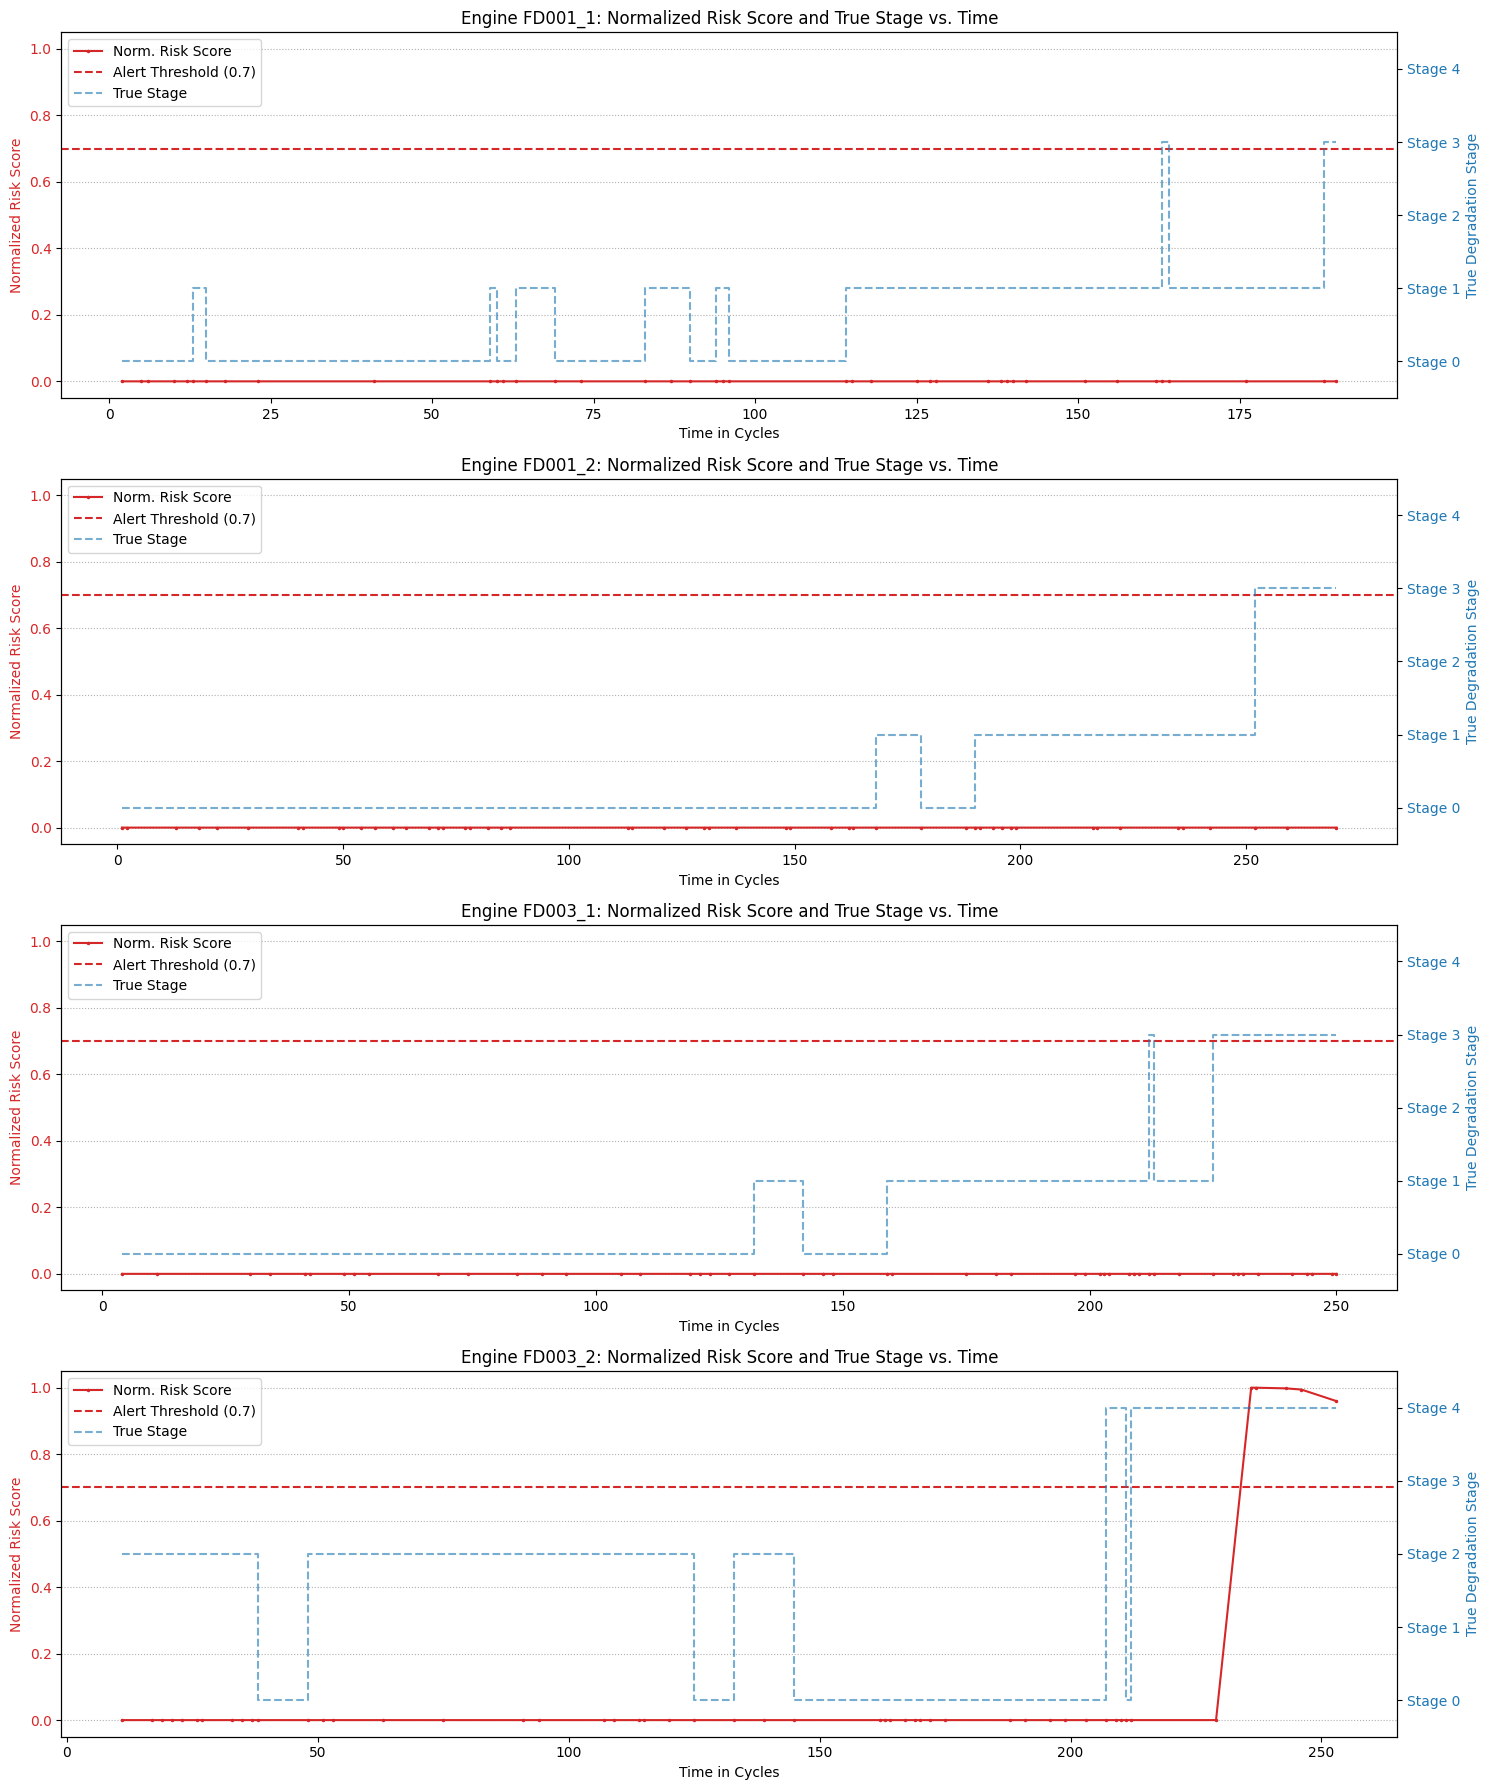


Phase 4 Complete
Risk score calculated, normalized, and alerts generated.


In [78]:
print("\nPlotting Normalized Risk Score trends for sample engines...")

# Ensure data is sorted for plotting lines correctly
df_val_results_sorted = df_val_results.sort_values(by=['unit_number', 'time_in_cycles'])

plt.figure(figsize=(15, len(PLOT_SAMPLE_ENGINES) * 4.5))
for i, engine_id in enumerate(PLOT_SAMPLE_ENGINES):
    engine_data = df_val_results_sorted[df_val_results_sorted['unit_number'] == engine_id]

    if not engine_data.empty:
        ax1 = plt.subplot(len(PLOT_SAMPLE_ENGINES), 1, i + 1)

        # Plot Normalized Risk Score on primary axis
        color = 'tab:red'
        ax1.set_xlabel('Time in Cycles')
        ax1.set_ylabel('Normalized Risk Score', color=color)
        ax1.plot(engine_data['time_in_cycles'], engine_data['normalized_risk_score'], color=color, label='Norm. Risk Score', marker='.', markersize=3)
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.axhline(y=RISK_THRESHOLD, color=color, linestyle='--', linewidth=1.5, label=f'Alert Threshold ({RISK_THRESHOLD})')
        ax1.set_ylim(-0.05, 1.05)
        ax1.grid(True, axis='y', linestyle=':')

        # Plot True Degradation Stage on secondary y-axis
        ax2 = ax1.twinx() # instantiate a second axes that shares the same x-axis
        color = 'tab:blue'
        ax2.set_ylabel('True Degradation Stage', color=color)
        ax2.step(engine_data['time_in_cycles'], engine_data['true_stage'], where='post', color=color, alpha=0.6, linestyle='--', linewidth=1.5, label='True Stage')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.set_yticks(range(N_CLUSTERS))
        ax2.set_yticklabels([f'Stage {j}' for j in range(N_CLUSTERS)])
        ax2.set_ylim(-0.5, N_CLUSTERS - 0.5)

        plt.title(f'Engine {engine_id}: Normalized Risk Score and True Stage vs. Time')

        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    else:
        ax = plt.subplot(len(PLOT_SAMPLE_ENGINES), 1, i + 1)
        ax.text(0.5, 0.5, f'Engine {engine_id} not found in validation set',
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_title(f'Engine {engine_id}: No Data')

plt.tight_layout()
plt.show()
print("\nPhase 4 Complete")
print("Risk score calculated, normalized, and alerts generated.")

Plotting Risk score over time for all engines

In [79]:
output_plot_dir = f"engine_risk_plots_{COMBINED_DATASET_NAME}"

try:
    os.makedirs(output_plot_dir, exist_ok=True) # Create directory if it doesn't exist
    print(f"Plots will be saved in directory: '{output_plot_dir}'")
except OSError as error:
    print(f"Error creating directory {output_plot_dir}: {error}")
    exit()

#Ensure data is sorted for plotting lines correctly
df_val_results_sorted = df_val_results.sort_values(by=['unit_number', 'time_in_cycles'])

#Get list of unique engines in the validation set
engines_in_validation = df_val_results_sorted['unit_number'].unique()
print(f"Found {len(engines_in_validation)} unique engines in the validation set.")

#Loop through each engine and create/save a plot
plot_count = 0
for engine_id in engines_in_validation:
    engine_data = df_val_results_sorted[df_val_results_sorted['unit_number'] == engine_id]
    if not engine_data.empty:
        fig, ax1 = plt.subplots(figsize=(12, 6))
        # Plot Normalized Risk Score on primary axis
        color = 'tab:red'
        ax1.set_xlabel('Time in Cycles')
        ax1.set_ylabel('Normalized Risk Score', color=color)
        ax1.plot(engine_data['time_in_cycles'], engine_data['normalized_risk_score'], color=color, label='Norm. Risk Score', marker='.', markersize=4)
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.axhline(y=RISK_THRESHOLD, color=color, linestyle='--', linewidth=1.5, label=f'Alert Threshold ({RISK_THRESHOLD})')
        ax1.set_ylim(-0.05, 1.05)
        ax1.grid(True, axis='y', linestyle=':')

        # Plot True Degradation Stage on secondary y-axis
        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('True Degradation Stage', color=color)
        ax2.step(engine_data['time_in_cycles'], engine_data['true_stage'], where='post', color=color, alpha=0.7, linestyle='--', linewidth=1.5, label='True Stage')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.set_yticks(range(N_CLUSTERS))
        ax2.set_yticklabels([f'Stage {j}' for j in range(N_CLUSTERS)])
        ax2.set_ylim(-0.5, N_CLUSTERS - 0.5)

        plt.title(f'Engine {engine_id}: Normalized Risk Score and True Stage vs. Time')

        # Combine legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')
        plot_filename = f"engine_{str(engine_id)}_risk_trend.png"
        plot_filepath = os.path.join(output_plot_dir, plot_filename)
        try:
            plt.savefig(plot_filepath)
            plot_count += 1
        except Exception as e:
            print(f"Warning: Could not save plot for engine {engine_id} to {plot_filepath}. Error: {e}")
        plt.close(fig)

print(f"\nFinished plotting. Saved {plot_count} plots to '{output_plot_dir}'.")

#Phase 4 Completion
print("\nPhase 4 Complete")
print("Risk score calculated, normalized, alerts generated, and individual plots saved.")

Plots will be saved in directory: 'engine_risk_plots_FD001+FD003'
Found 200 unique engines in the validation set.

Finished plotting. Saved 200 plots to 'engine_risk_plots_FD001+FD003'.

Phase 4 Complete
Risk score calculated, normalized, alerts generated, and individual plots saved.
